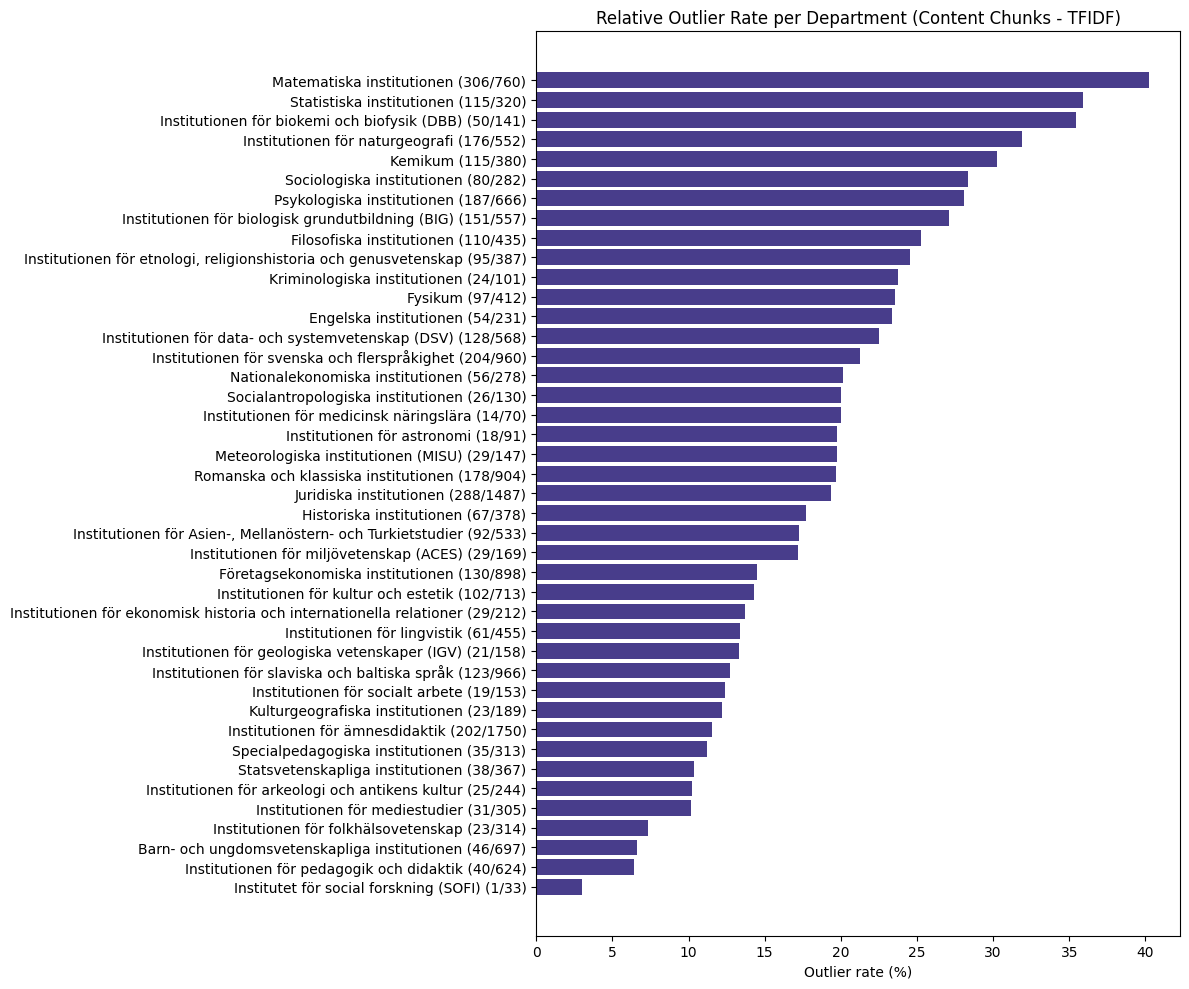

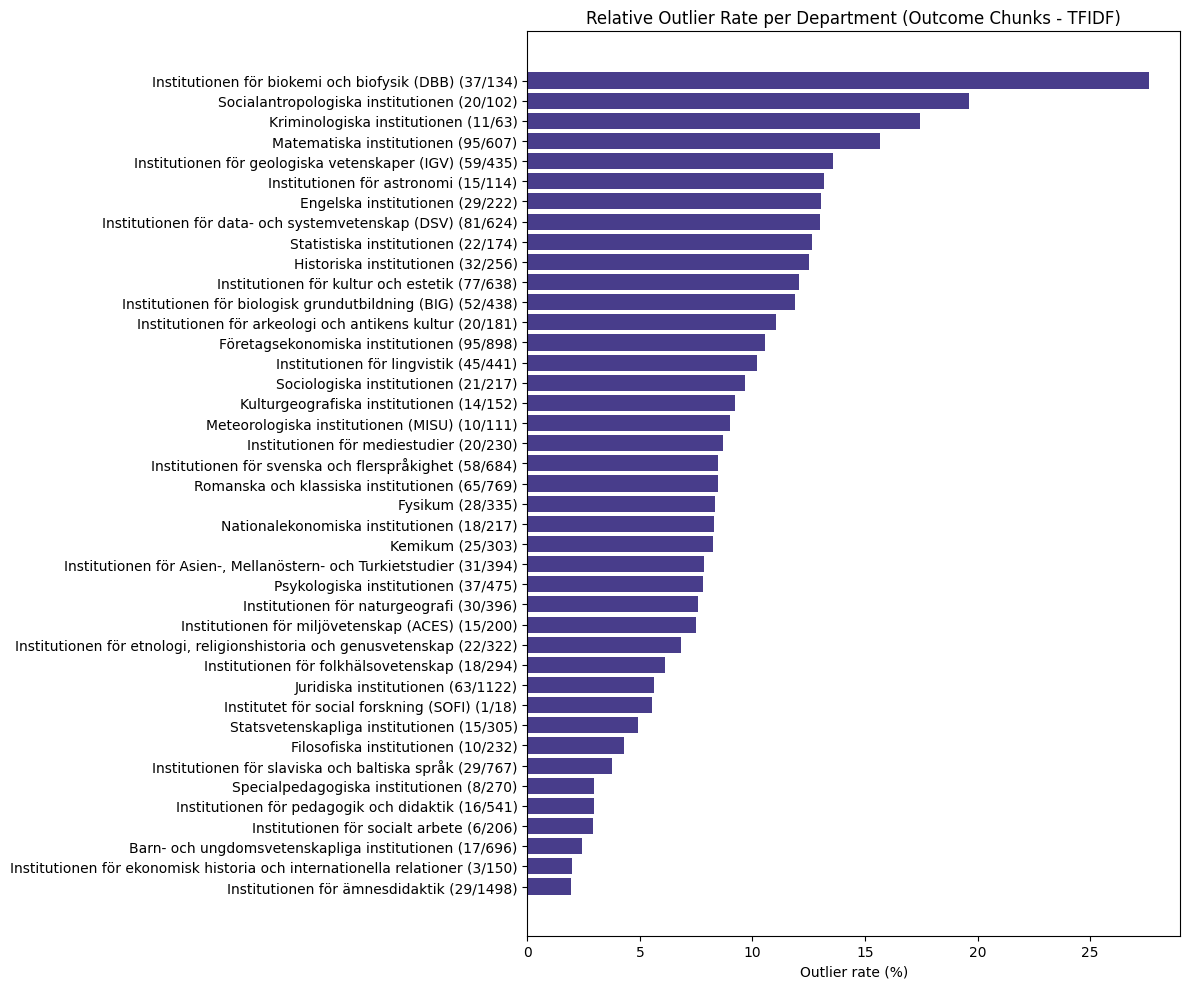

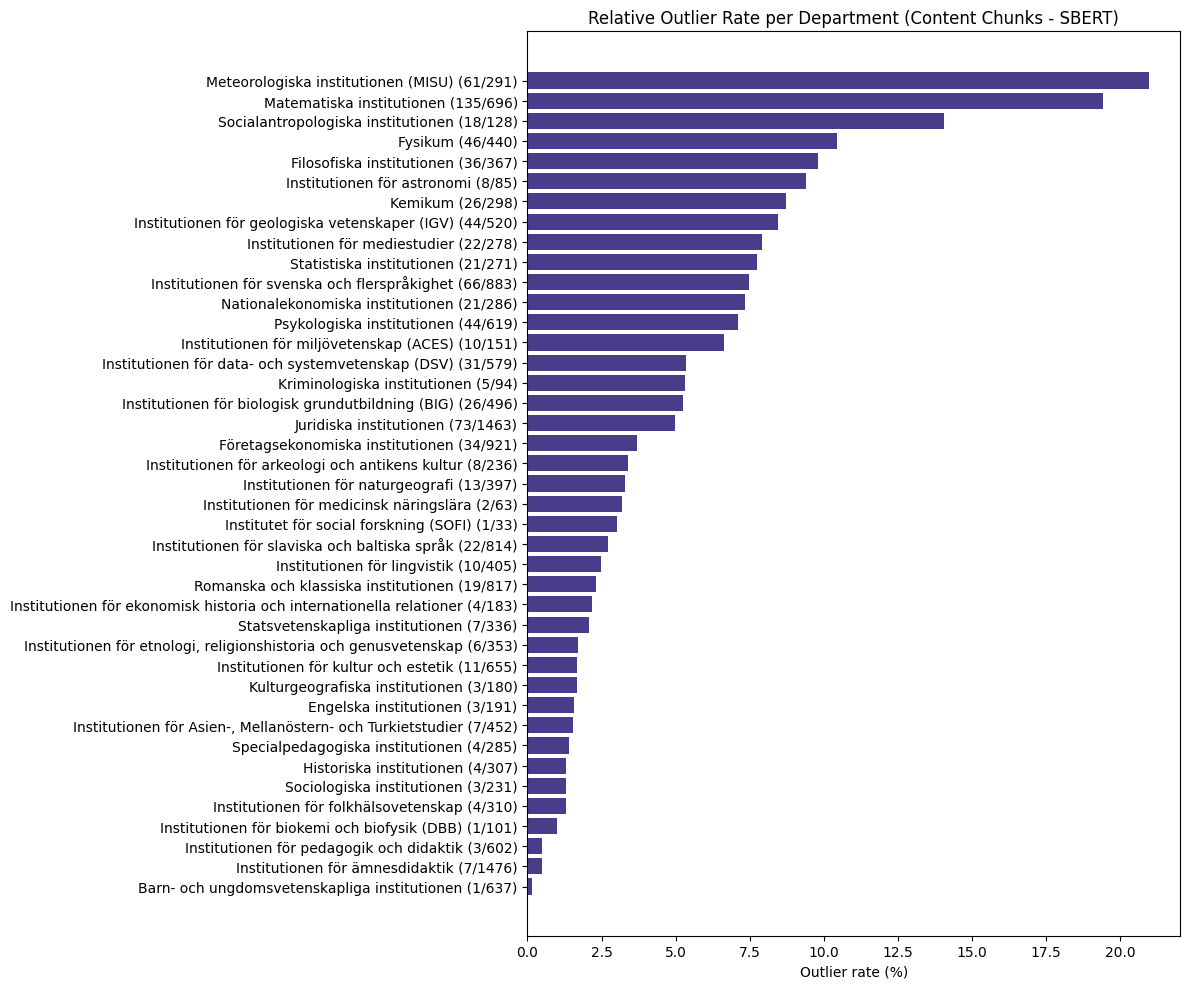

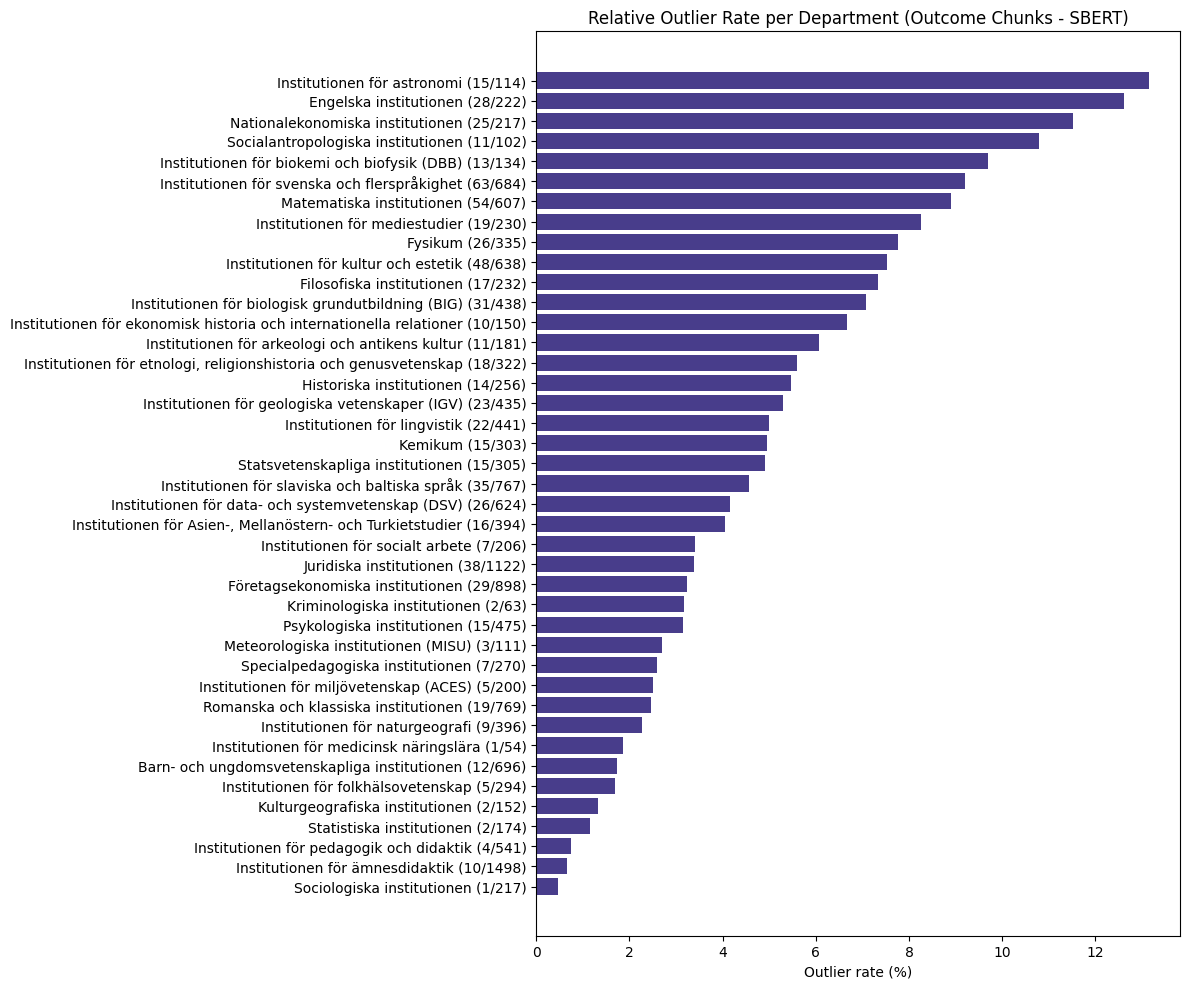

In [1]:
import json
import matplotlib.pyplot as plt

for method in ['tfidf', 'sbert']:
     for per in ['content', 'outcome']:
        with open(f'../data/{per}.{method}.similarities.json', 'r') as f:
            data = json.load(f)

        with open(f'../data/outliers.{per}.{method}.json', 'r') as f:
            outliers = json.load(f)

        with open('../data/SU.departments.json', 'r') as f:
            dept = json.load(f)

        with open('../data/SU.filtered.json', 'r') as f:
            corpus = json.load(f)

        course_departments = {course['CourseCode']: course['Department'] for course in corpus['Course-list']}

        dept_chunk_counts = {}
        for course_code, course in data.items():
            department = course_departments.get(course_code, 'Unknown')
            dept_chunk_counts[department] = dept_chunk_counts.get(department, 0) + len((course['chunks'] if per == 'content' else course['outcomes']))

        dept_outlier_counts = {}
        for outlier in outliers:
            dept_code = course_departments.get(outlier['course_code'], 'Unknown')
            dept_outlier_counts[dept_code] = dept_outlier_counts.get(dept_code, 0) + 1

        relative_counts = {}
        for dept_code, out_count in dept_outlier_counts.items():
            chunk_count = dept_chunk_counts.get(dept_code, 0)
            if chunk_count > 0:
                relative_counts[dept_code] = out_count / chunk_count  # fraction

        pairs = sorted(relative_counts.items(), key=lambda x: x[1], reverse=True)

        if pairs:
            dept_codes = [p[0] for p in pairs]
            rates_pct = [p[1] * 100 for p in pairs]  # percent
            labels = [
                f"{dept.get(code, code)} ({dept_outlier_counts.get(code, 0)}/{dept_chunk_counts.get(code, 0)})"
                for code in dept_codes
            ]

            plt.figure(figsize=(12, 10))
            plt.barh(labels, rates_pct, color='darkslateblue')
            plt.xlabel('Outlier rate (%)')
            # plt.ylabel('Department')
            plt.title(f'Relative Outlier Rate per Department ({per.capitalize()} Chunks - {method.upper()})')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.savefig(f'../data/{method}_outlier_rates_per_{per}.png')


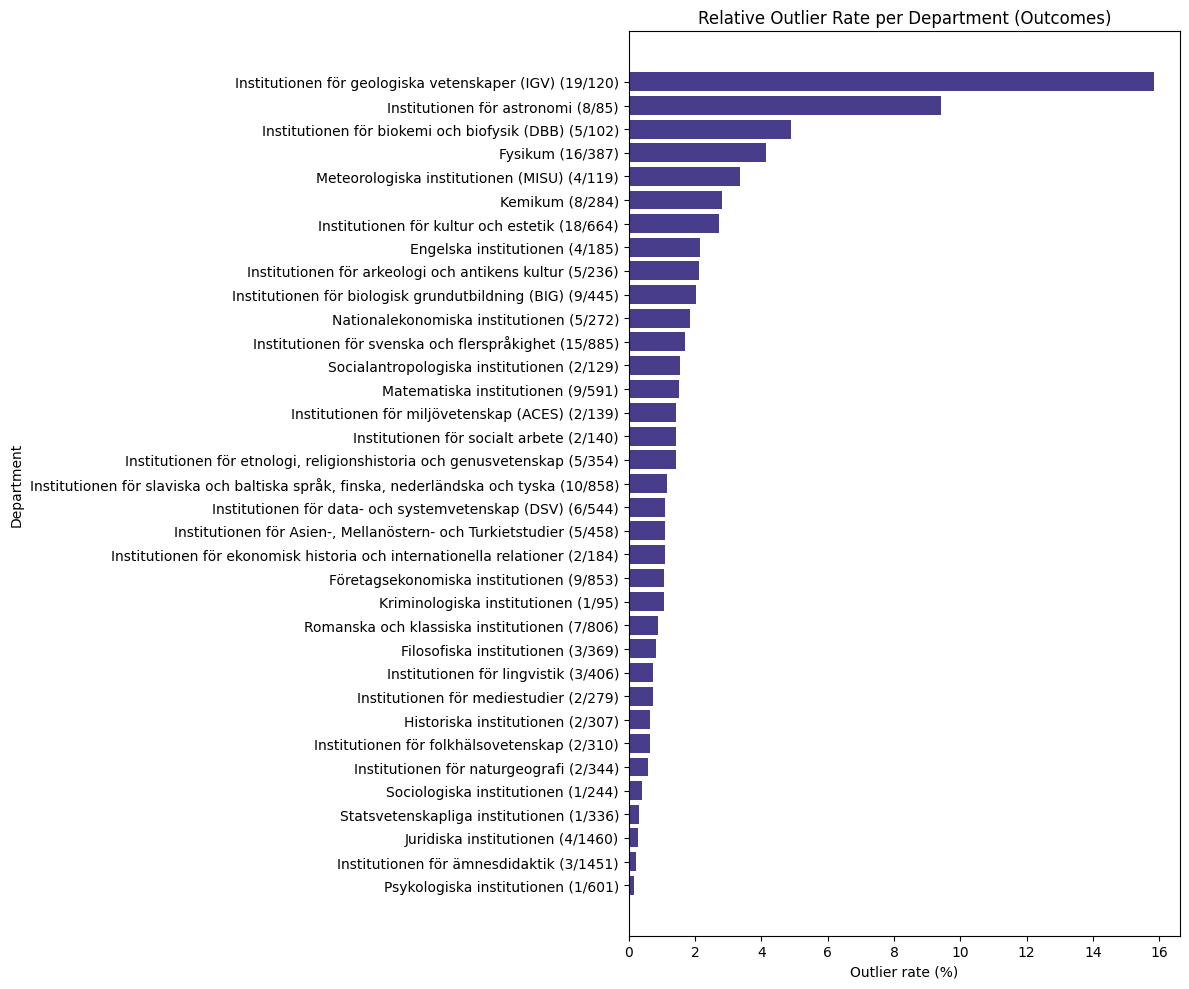

In [ ]:
import json
import matplotlib.pyplot as plt

with open('../data/outcome.sbert.similarities.json', 'r') as f:
    data = json.load(f)
with open('../data/outliers.outcome.json', 'r') as f:
    outliers = json.load(f)
with open('../data/SU.departments.json', 'r') as f:
    dept = json.load(f)
with open('../data/SU.filtered.json', 'r') as f:
    corpus = json.load(f)

course_departments = {course['CourseCode']: course['Department'] for course in corpus['Course-list']}

# Count content_chunks per department
dept_chunk_counts = {}
for course_code, course in data.items():
    department = course_departments.get(course_code, 'Unknown')
    dept_chunk_counts[department] = dept_chunk_counts.get(department, 0) + len(course['content_chunks'])

# Count outliers per department
dept_outlier_counts = {}
for outlier in outliers:
    dept_code = course_departments.get(outlier['course_code'], 'Unknown')
    dept_outlier_counts[dept_code] = dept_outlier_counts.get(dept_code, 0) + 1

# Compute relative outlier rate per department
relative_counts = {}
for dept_code, out_count in dept_outlier_counts.items():
    chunk_count = dept_chunk_counts.get(dept_code, 0)
    if chunk_count > 0:
        relative_counts[dept_code] = out_count / chunk_count

pairs = sorted(relative_counts.items(), key=lambda x: x[1], reverse=True)

if pairs:
    dept_codes = [p[0] for p in pairs]
    rates_pct = [p[1] * 100 for p in pairs]
    labels = [
        f"{dept.get(code, code)} ({dept_outlier_counts.get(code, 0)}/{dept_chunk_counts.get(code, 0)})"
        for code in dept_codes
    ]

    plt.figure(figsize=(12, 10))
    plt.barh(labels, rates_pct, color='darkslateblue')
    plt.xlabel('Outlier rate (%)')
    plt.ylabel('Department')
    plt.title('Relative Outlier Rate per Department (Outcomes)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [3]:
import json

methods = ['tfidf', 'sbert']
pers = ['content', 'outcome']

with open('../data/SU.departments.json', 'r') as f:
    dept_names = json.load(f)

with open('../data/SU.filtered.json', 'r') as f:
    corpus = json.load(f)

course_departments = {
    course['CourseCode']: course['Department']
    for course in corpus['Course-list']
}

# Collect results in nested dict:
# results[department][(method, per)] = (rate, outliers, total)
results = {}
all_departments = set()

for method in methods:
    for per in pers:
        with open(f'../data/{per}.{method}.similarities.json', 'r') as f:
            data = json.load(f)

        with open(f'../data/outliers.{per}.{method}.json', 'r') as f:
            outliers = json.load(f)

        dept_unit_counts = {}
        for course_code, course in data.items():
            department = course_departments.get(course_code, 'Unknown')
            units = course['chunks'] if per == 'content' else course['outcomes']
            dept_unit_counts[department] = dept_unit_counts.get(department, 0) + len(units)
            all_departments.add(department)

        dept_outlier_counts = {}
        for outlier in outliers:
            department = course_departments.get(outlier['course_code'], 'Unknown')
            dept_outlier_counts[department] = dept_outlier_counts.get(department, 0) + 1
            all_departments.add(department)

        for department in all_departments:
            total = dept_unit_counts.get(department, 0)
            out_count = dept_outlier_counts.get(department, 0)
            rate = (out_count / total * 100) if total > 0 else 0.0

            if department not in results:
                results[department] = {}

            results[department][(method, per)] = (rate, out_count, total)

# Sort departments by readable department name
sorted_departments = sorted(
    all_departments,
    # key=lambda d: dept_names.get(d, d)
)

# Build LaTeX table
lines = []
lines.append(r"\begin{table}[ht]")
lines.append(r"    \centering")
lines.append(r"    \small")
lines.append(r"    \begin{tabular}{lcccc}")
lines.append(r"        \hline")
lines.append(r"        Department & SBERT Content & SBERT Outcome & TF-IDF Content & TF-IDF Outcome \\")
lines.append(r"        \hline")

for dept_code in sorted_departments:
    dept_label = dept_code #dept_names.get(dept_code, dept_code)

    def format_cell(method, per):
        rate, out_count, total = results.get(dept_code, {}).get((method, per), (0.0, 0, 0))
        return f"{rate:.1f}\\% ({out_count}/{total})"
        # return f"{rate:.1f}\\%"


    row = (
        f"        {dept_label} & "
        f"{format_cell('sbert', 'content')} & "
        f"{format_cell('sbert', 'outcome')} & "
        f"{format_cell('tfidf', 'content')} & "
        f"{format_cell('tfidf', 'outcome')} \\\\"
    )
    lines.append(row)

lines.append(r"        \hline")
lines.append(r"    \end{tabular}")
lines.append(r"    \caption{Relative outlier rates per department for each method and matching direction. Percentages are shown together with absolute outlier counts over total evaluated units.}")
lines.append(r"    \label{tab:dept_outlier_rates}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)

with open("../data/dept_outlier_rates_table.tex", "w") as f:
    f.write(latex_table)

print(latex_table)

\begin{table}[ht]
    \centering
    \small
    \begin{tabular}{lcccc}
        \hline
        Department & SBERT Content & SBERT Outcome & TF-IDF Content & TF-IDF Outcome \\
        \hline
        102 & 9.8\% (36/367) & 7.3\% (17/232) & 25.3\% (110/435) & 4.3\% (10/232) \\
        103 & 1.7\% (6/353) & 5.6\% (18/322) & 24.5\% (95/387) & 6.8\% (22/322) \\
        104 & 1.3\% (4/307) & 5.5\% (14/256) & 17.7\% (67/378) & 12.5\% (32/256) \\
        106 & 1.7\% (11/655) & 7.5\% (48/638) & 14.3\% (102/713) & 12.1\% (77/638) \\
        108 & 3.4\% (8/236) & 6.1\% (11/181) & 10.2\% (25/244) & 11.0\% (20/181) \\
        120 & 7.9\% (22/278) & 8.3\% (19/230) & 10.2\% (31/305) & 8.7\% (20/230) \\
        130 & 0.5\% (7/1476) & 0.7\% (10/1498) & 11.5\% (202/1750) & 1.9\% (29/1498) \\
        150 & 1.6\% (3/191) & 12.6\% (28/222) & 23.4\% (54/231) & 13.1\% (29/222) \\
        153 & 2.5\% (10/405) & 5.0\% (22/441) & 13.4\% (61/455) & 10.2\% (45/441) \\
        154 & 7.5\% (66/883) & 9.2\% (63/684) &

In [1]:
import json
import numpy as np
import pandas as pd

with open('../data/content.sbert.similarities.json', 'r') as f:
    chunk_to_outcome = json.load(f)

with open('../data/outcome.sbert.similarities.json', 'r') as f:
    outcome_to_chunk = json.load(f)

with open('../data/SU.filtered.json', 'r') as f:
    su_filtered = json.load(f)

# use the intersection just in case some courses are missing from one file
course_codes = set(chunk_to_outcome.keys()) & set(outcome_to_chunk.keys())

metadata = {}

for course in su_filtered['Course-list']:
    code = course['CourseCode']
    metadata[code] = {
        'Department': course['Department'],
        'Year': course['ValidFrom'][:4],
        'Credits': course['ECTS-credits'],
        'ContentLength': len(course['CourseContent'].split())
    }

rows = []

for code in course_codes:
    c2o_course = chunk_to_outcome[code]
    o2c_course = outcome_to_chunk[code]

    # chunk -> outcome:
    # each chunk object already stores its best-matching outcome similarity
    c2o_scores = [chunk["max_similarity"] for chunk in c2o_course["chunks"]]

    # outcome -> chunk:
    # each outcome object already stores its best-matching chunk similarity
    o2c_scores = [outcome["max_similarity"] for outcome in o2c_course["outcomes"]]

    # protect against empty lists just in case
    mean_c2o = np.mean(c2o_scores) if c2o_scores else np.nan
    mean_o2c = np.mean(o2c_scores) if o2c_scores else np.nan

    std_c2o = np.std(c2o_scores) if c2o_scores else np.nan
    std_o2c = np.std(o2c_scores) if o2c_scores else np.nan

    year = metadata[code]['Year']
    credits = metadata[code]['Credits']
    content_len = metadata[code]['ContentLength']
    department = metadata[code]['Department']

    rows.append({
        "CourseCode": code,
        "Department": department,
        "Content-to-ILO": round(mean_c2o, 4),
        "ILO-to-Content": round(mean_o2c, 4),
        # "ChunkToOutcomeStd": round(std_c2o, 4),
        # "OutcomeToChunkStd": round(std_o2c, 4),
        "# Chunks": len(c2o_scores),
        "# Outcomes": len(o2c_scores),
        "Year": year,
        "Credits": float(credits.replace(',', '.')),
        "Content Length": content_len
    })

df = pd.DataFrame(rows)

df.to_csv('../data/course_alignment_with_metadata.csv', index=False)

In [2]:
import pandas as pd
from scipy.stats import spearmanr

columns = ['Content-to-ILO', 
           'ILO-to-Content',
           '# Chunks',
           '# Outcomes',
           'Year',
           'Credits',
           'Content Length']

df = pd.read_csv('../data/course_alignment_with_metadata.csv')
res = df[columns].corr(method = "spearman", numeric_only=True)

res = res.loc[['Content-to-ILO', 'ILO-to-Content']]

res

,Content-to-ILO,ILO-to-Content,# Chunks,# Outcomes,Year,Credits,Content Length
Content-to-ILO,1.000000,0.611358,-0.284506,0.018651,0.131597,-0.1047,-0.055562
ILO-to-Content,0.611358,1.000000,0.116338,-0.174043,0.121072,-0.1233,0.162449


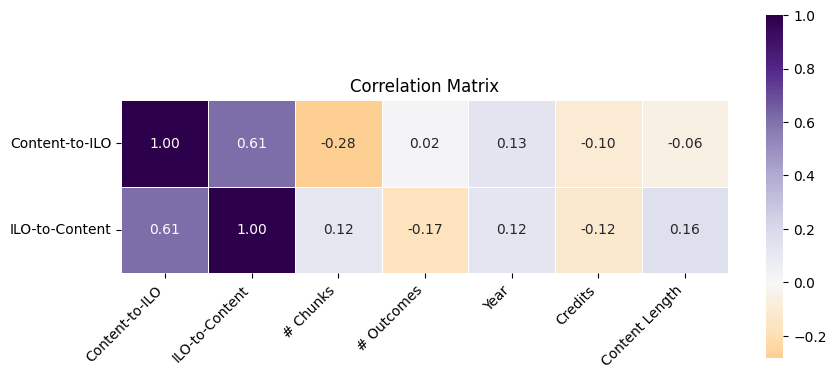

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,4))

sns.heatmap(
    res,
    annot=True,
    cmap='PuOr',
    center=0,
    fmt='.2f',
    square=True,
    linewidths=.5
)

plt.xticks(rotation=45, ha='right')

plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../visualisations/correlation_matrix.png', dpi=300)
plt.show()


In [4]:
import json

def get_bottom_k(items, k=30):
    return sorted(items, key=lambda x: x["similarity"])[:k]

with open('../data/outcome.sbert.similarities.json', 'r') as f:
    outcome_data = json.load(f)

with open('../data/content.sbert.similarities.json', 'r') as f:
    content_data = json.load(f)

with open('../data/SU.filtered.json', 'r') as f:
    corpus = json.load(f)

course_deps = {}
for course in corpus['Course-list']:
    course_deps[course['CourseCode']] = course.get('Department', 'Unknown')

# ILO -> Content
outcome_items = []

for course_code, course in outcome_data.items():
    department = course_deps.get(course_code, None)

    for outcome in course["outcomes"]:
        outcome_items.append({
            "course_code": course_code,
            "department": department,
            "outcome": outcome["outcome"],
            "similarity": outcome["max_similarity"],
            "matched_chunk": outcome["matched_chunk"],
            "category": ''
        })

lowest_outcomes = get_bottom_k(outcome_items, k=50)


# Content -> ILO
content_items = []

for course_code, course in content_data.items():
    department = course_deps.get(course_code, None)

    for chunk in course["chunks"]:
        content_items.append({
            "course_code": course_code,
            "department": department,
            "chunk": chunk["chunk"],
            "similarity": chunk["max_similarity"],
            "matched_outcome": chunk["matched_outcome"],
            "category": ''
        })

lowest_chunks = get_bottom_k(content_items, k=50)

output = {
    "lowest_ilos_to_content": lowest_outcomes,
    "lowest_content_to_ilos": lowest_chunks
}

with open('../data/lowest_alignment_sbert.json', 'w') as f:
    json.dump(output, f, indent=2)

In [7]:
import json
import pandas as pd

with open('../data/lowest_alignment_sbert.json', 'r') as f:
    lowest_alignment = json.load(f)

df = pd.DataFrame(lowest_alignment['lowest_ilos_to_content'])

# get counts for categories
categories = { '1': 'Pre-processing error',
               '2': 'True Misalignment',
               '3': 'Unidentified Alignment',
                '4': 'Ambiguous' }
category_counts = df['category'].value_counts()
print("Category Counts:")
for cat, count in category_counts.items():
    print(f"{categories.get(cat, cat)}: {count}")

dep_counts = df['department'].value_counts()
print("\nDepartment Counts:")
for dep, count in dep_counts.items():
    print(f"{dep}: {count}")    

Category Counts:
Pre-processing error: 27
True Misalignment: 15
Unidentified Alignment: 7
Ambiguous: 1

Department Counts:
402: 5
106: 4
172: 4
401: 3
108: 3
431: 3
165: 3
434: 2
104: 2
333: 2
460: 2
463: 2
102: 2
464: 2
323: 2
485: 1
120: 1
302: 1
403: 1
320: 1
310: 1
154: 1
305: 1
158: 1


/var/folders/qy/sdsn3j791r3_yqzfwgmv6kd40000gn/T/ipykernel_95294/219740431.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=df, palette='PuOr')


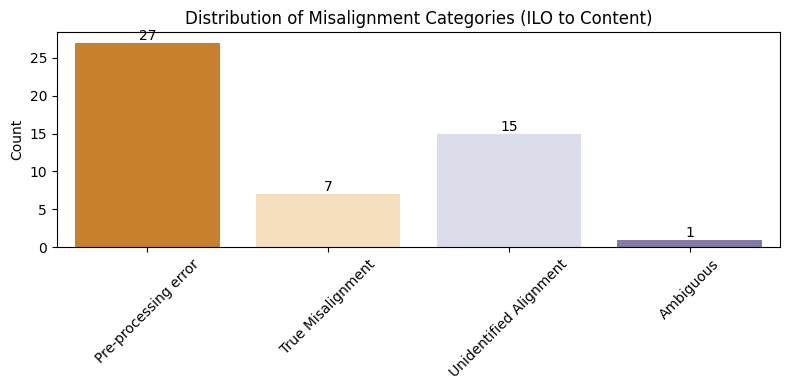

In [ ]:
# Visualise the category distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='category', data=df, palette='PuOr')
plt.xlabel('')
plt.ylabel('Count')
# Add counts on bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
plt.xticks(ticks=range(len(categories)), labels=[categories.get(str(i), str(i)) for i in range(1, len(categories)+1)], rotation=45)
plt.title('Distribution of Misalignment Categories (ILO to Content)')
plt.tight_layout()
plt.savefig('../visualisations/outcome_bottom50_category_distribution.png', dpi=300)
plt.show()
